# 15 — lmfit superpixel inversion with the bi_jax water model

Adapted from `bio_optics/notebooks/15_lmfit_superpixel_bi.ipynb`.
Data loading and output saving use the Helsinki EnMAP S3 store.

| Layer | Module | Role |
|---|---|---|
| Layer 1 — solver | `lmfit_engine` | per-spectrum Levenberg–Marquardt LSQ |
| Layer 2 — image  | `superpixel_engine` | SLIC segmentation + PCA/kNN back-interpolation |

Forward model: **bi_jax** (Bi et al. 2023, HEREON water optical model).

Free parameters: `C_*` (phytoplankton types), `C_Y` (CDOM), `C_ism` (ISM).

## 1  Imports & configuration

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import lmfit
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.ndimage as ndi
import xarray as xr
import rioxarray
from pyproj import CRS
from xcube.core.store import new_data_store
import configparser

from bio_optics.water.reflectance import bi_jax
from bio_optics.inversion import lmfit_engine
from bio_optics.image_processing import superpixel_engine

In [2]:
# --- inversion config --------------------------------------------------------
NOISE       = 0.001    # Rrs noise level [sr-1]
N_SEGMENTS  = 1000     # target SLIC superpixel count
COMPACTNESS = 0.1      # SLIC: low = spectral boundaries dominate
SLIC_SIGMA  = 2.0      # SLIC: Gaussian smoothing
K           = 4        # kNN neighbours for back-interpolation
N_COMPONENTS = 6       # PCA dimensions for spectral embedding
MAX_NFEV    = 400      # max lmfit function evaluations per spectrum

## 2  Load image data — Helsinki EnMAP S3 store

In [3]:
config = configparser.ConfigParser()
config.read('../../config.ini')
credentials = {k: v.strip() for k, v in config['Credentials'].items()}

store = new_data_store(
    's3', max_depth=5, root='coastal-cubes/sek/',
    storage_options=dict(
        anon=False,
        key=credentials['s3_client_id'],
        secret=credentials['s3_client_secret'],
    )
)

INPUT_PREFIX  = 'helsinki/L2A_land/'
OUTPUT_PREFIX = 'helsinki/temp/'

scene_id = 'ENMAP01-____L2A-DT0000158841_20251019T101424Z_002_V010505_20260206T113145Z'

img         = store.open_data(f'{INPUT_PREFIX}{scene_id}.zarr')
scene_crs   = img.rio.crs or CRS.from_wkt(img.spatial_ref.attrs['crs_wkt'])
wavelengths = img.wavelength.values[:80]

refl  = img['reflectance'].isel(band=slice(0, 80))
rrs   = (refl.where(refl > -32768) / 10_000) / np.pi
cloud = (img['cloud'] == 1) | (img['cirrus'] == 1) | (img['haze'] == 1)
rrs   = rrs.where(~cloud)

# ocean mask (connected water bodies ≥ 100 px)
_wc = store.open_data(f'{OUTPUT_PREFIX}{scene_id}-worldcover.zarr')
_wf = _wc['water_fraction'].values
_labeled, _ = ndi.label(_wf >= 0.5)
_sizes = np.bincount(_labeled.ravel())
_sizes[0] = 0
ocean_mask = xr.DataArray(
    np.isin(_labeled, np.where(_sizes >= 100)[0]),
    coords=_wc['water_fraction'].coords, dims=_wc['water_fraction'].dims,
)
rrs = rrs.where(ocean_mask)

Rrs_arr = rrs.transpose('y', 'x', 'band').values

print(f'Image shape : {Rrs_arr.shape}')
print(f'Wavelengths : {wavelengths[0]:.1f} – {wavelengths[-1]:.1f} nm ({len(wavelengths)} bands)')

Image shape : (1285, 1302, 80)
Wavelengths : 418.4 – 902.0 nm (80 bands)


## 3  Precompute spectral tables

In [4]:
pre = bi_jax.precompute(wavelengths)
print(f'n_phy_classes : {pre["n_classes"]}')

n_phy_classes : 8


## 4  Define lmfit parameters

Free parameters: `C_0`, `C_Y`, `C_ism`, `offset`.  
Everything else is fixed to literature defaults.

In [5]:
params = lmfit.Parameters()

# --- free parameters --------------------------------------------------------
params.add('C_0',   value=2.0,  min=0.0,   max=200.0, vary=True)   # phy class 0 [ug/L]
params.add('C_1',   value=2.0,  min=0.0,   max=200.0, vary=True)   # phy class 1 [ug/L]
params.add('C_2',   value=2.0,  min=0.0,   max=200.0, vary=True)   # phy class 2 [ug/L]
params.add('C_3',   value=2.0,  min=0.0,   max=200.0, vary=True)   # phy class 3 [ug/L]
params.add('C_4',   value=2.0,  min=0.0,   max=200.0, vary=True)   # phy class 4 [ug/L]
params.add('C_5',   value=2.0,  min=0.0,   max=200.0, vary=True)   # phy class 5 [ug/L]
params.add('C_6',   value=2.0,  min=0.0,   max=200.0, vary=True)   # phy class 6 [ug/L]
params.add('C_7',   value=2.0,  min=0.0,   max=200.0, vary=True)   # phy class 7 [ug/L]
params.add('C_Y',   value=0.2,  min=0.0,   max=10.0,  vary=True)   # CDOM abs at lambda_0_cdom [1/m]
params.add('C_ism', value=2.0,  min=0.0,   max=200.0, vary=True)   # ISM [g/m3]
params.add('offset',value=0.0,  min=-0.02, max=0.02,  vary=False)   # spectral offset [sr-1]

# --- CDOM -------------------------------------------------------------------
params.add('S_cdom',        value=0.014, vary=False)
params.add('lambda_0_cdom', value=440.0, vary=False)
params.add('K',             value=0.0,   vary=False)

# --- minerogenic detritus absorption ----------------------------------------
params.add('A_md',        value=0.04,  vary=False)
params.add('S_md',        value=0.011, vary=False)
params.add('C_md',        value=0.0,   vary=False)
params.add('lambda_0_md', value=440.0, vary=False)

# --- biogenic detritus absorption -------------------------------------------
params.add('A_bd',        value=0.001, vary=False)
params.add('S_bd',        value=0.011, vary=False)
params.add('C_bd',        value=0.0,   vary=False)
params.add('lambda_0_bd', value=440.0, vary=False)

# --- detritus attenuation ---------------------------------------------------
params.add('gamma_d',     value=0.5,   vary=False)
params.add('x0',          value=0.96,  vary=False)
params.add('x1',          value=0.5,   vary=False)
params.add('x2',          value=1.0,   vary=False)
params.add('lambda_0_c_d',value=550.0, vary=False)

# --- temperature ------------------------------------------------------------
params.add('T_W',   value=15.0, vary=False)
params.add('T_W_0', value=15.0, vary=False)

# --- phytoplankton packaging ------------------------------------------------
params.add('A_phy',        value=0.06,  vary=False)
params.add('E0',           value=0.65,  vary=False)
params.add('E1',           value=0.67,  vary=False)
params.add('lambda_0_phy', value=440.0, vary=False)

# --- backscattering ratios --------------------------------------------------
for i in range(8):
    params.add(f'b_ratio_C_{i}', value=0.01, vary=False)
params.add('b_ratio_md', value=0.02, vary=False)
params.add('b_ratio_bd', value=0.01, vary=False)

# --- Lee et al. (2011) coefficients ----------------------------------------
params.add('Gw0', value=0.0895, vary=False)
params.add('Gw1', value=0.1247, vary=False)
params.add('Gp0', value=0.0401, vary=False)
params.add('Gp1', value=0.0841, vary=False)

free = [n for n, p in params.items() if p.vary]
print(f'Free parameters ({len(free)}): {free}')

Free parameters (10): ['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_6', 'C_7', 'C_Y', 'C_ism']


## 5  Forward function adapter

`bi_jax.make_forward_vec` returns a flat-vector function that `jax.jit` can compile once.
The JIT-compiled function is then wrapped to accept lmfit Parameters, matching the
`lmfit_engine` signature `forward_func(params, wavelengths)`.

In [ ]:
param_names = list(params.keys())
_f_jit = jax.jit(bi_jax.make_forward_vec(param_names, pre))

def forward_func(params, wavelengths):
    """Adapter: lmfit_engine signature → bi_jax (JIT-compiled)."""
    params_vec = jnp.array([float(params[k]) for k in param_names])
    return np.array(_f_jit(params_vec))

# warm-up / trace (compiles the XLA program once)
_ = forward_func(params, wavelengths)

# quick sanity check
Rrs_test = forward_func(params, wavelengths)
print(f'Forward check — Rrs range: [{Rrs_test.min():.4f}, {Rrs_test.max():.4f}] sr-1')

plt.figure(figsize=(8, 3))
plt.plot(wavelengths, Rrs_test)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Rrs [sr⁻¹]')
plt.title('bi_jax forward — default parameters')
plt.tight_layout()

## 6  Build LmfitSetup

In [7]:
setup = lmfit_engine.build_inversion(
    params,
    wavelengths,
    forward_func,
    method='least-squares',
    max_nfev=MAX_NFEV,
)
print(f'fit_names : {setup.fit_names}')

fit_names : ['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_6', 'C_7', 'C_Y', 'C_ism']


## 7  Superpixel inversion

In [8]:
results = superpixel_engine.invert_image_superpixel(
    Rrs_arr,
    setup,
    NOISE,
    invert_fn=lmfit_engine.invert_image,
    n_segments=N_SEGMENTS,
    compactness=COMPACTNESS,
    sigma=SLIC_SIGMA,
    k=K,
    n_components=N_COMPONENTS,
    store_sp_results=True,
    store_chi2_spectral=True,
)

x_hat      = results['x_hat']           # (n_rows, n_cols, n_fit)
chi2       = results['chi2']            # (n_rows, n_cols)
chi2_cal   = results['chi2_calibrated']
chi2_sp    = results['chi2_spectral']   # (n_rows, n_cols) plain MSE, no noise weighting
success    = results['success']         # (n_rows, n_cols) bool
n_nfev     = results['n_nfev']         # (n_rows, n_cols) int
fit_names  = results['fit_names']
labels     = results['labels']
sp_counts  = results['sp_counts']

print(f'fit_names      : {fit_names}')
print(f'x_hat shape    : {x_hat.shape}')
print(f'n_superpixels  : {len(np.unique(labels))}')
print(f'median sp size : {np.median(sp_counts):.0f} px')

# convergence summary (water pixels only)
_w = success[np.isfinite(Rrs_arr).all(axis=-1)]
print(f'converged      : {_w.sum()} / {len(_w)} water pixels ({100*_w.mean():.1f}%)')

fit_names      : ['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_6', 'C_7', 'C_Y', 'C_ism']
x_hat shape    : (1285, 1302, 10)
n_superpixels  : 941
median sp size : 0 px
converged      : 0 / 232683 water pixels (0.0%)


## 7b  Save to S3 store

In [9]:
# coords_2d = {'y': rrs.y, 'x': rrs.x}
# ds = xr.Dataset({
#     'x_hat': xr.DataArray(
#         x_hat, dims=('y', 'x', 'param'),
#         coords={**coords_2d, 'param': fit_names},
#     ),
#     'chi2':            xr.DataArray(chi2,     dims=('y', 'x'), coords=coords_2d),
#     'chi2_calibrated': xr.DataArray(chi2_cal, dims=('y', 'x'), coords=coords_2d),
#     'chi2_spectral':   xr.DataArray(chi2_sp,  dims=('y', 'x'), coords=coords_2d),
# }).rio.write_crs(scene_crs)

# store.write_data(ds, f'{OUTPUT_PREFIX}{scene_id}-wq_params_lmfit_sp.zarr', replace=True)
# print('saved.')

## 8  Results

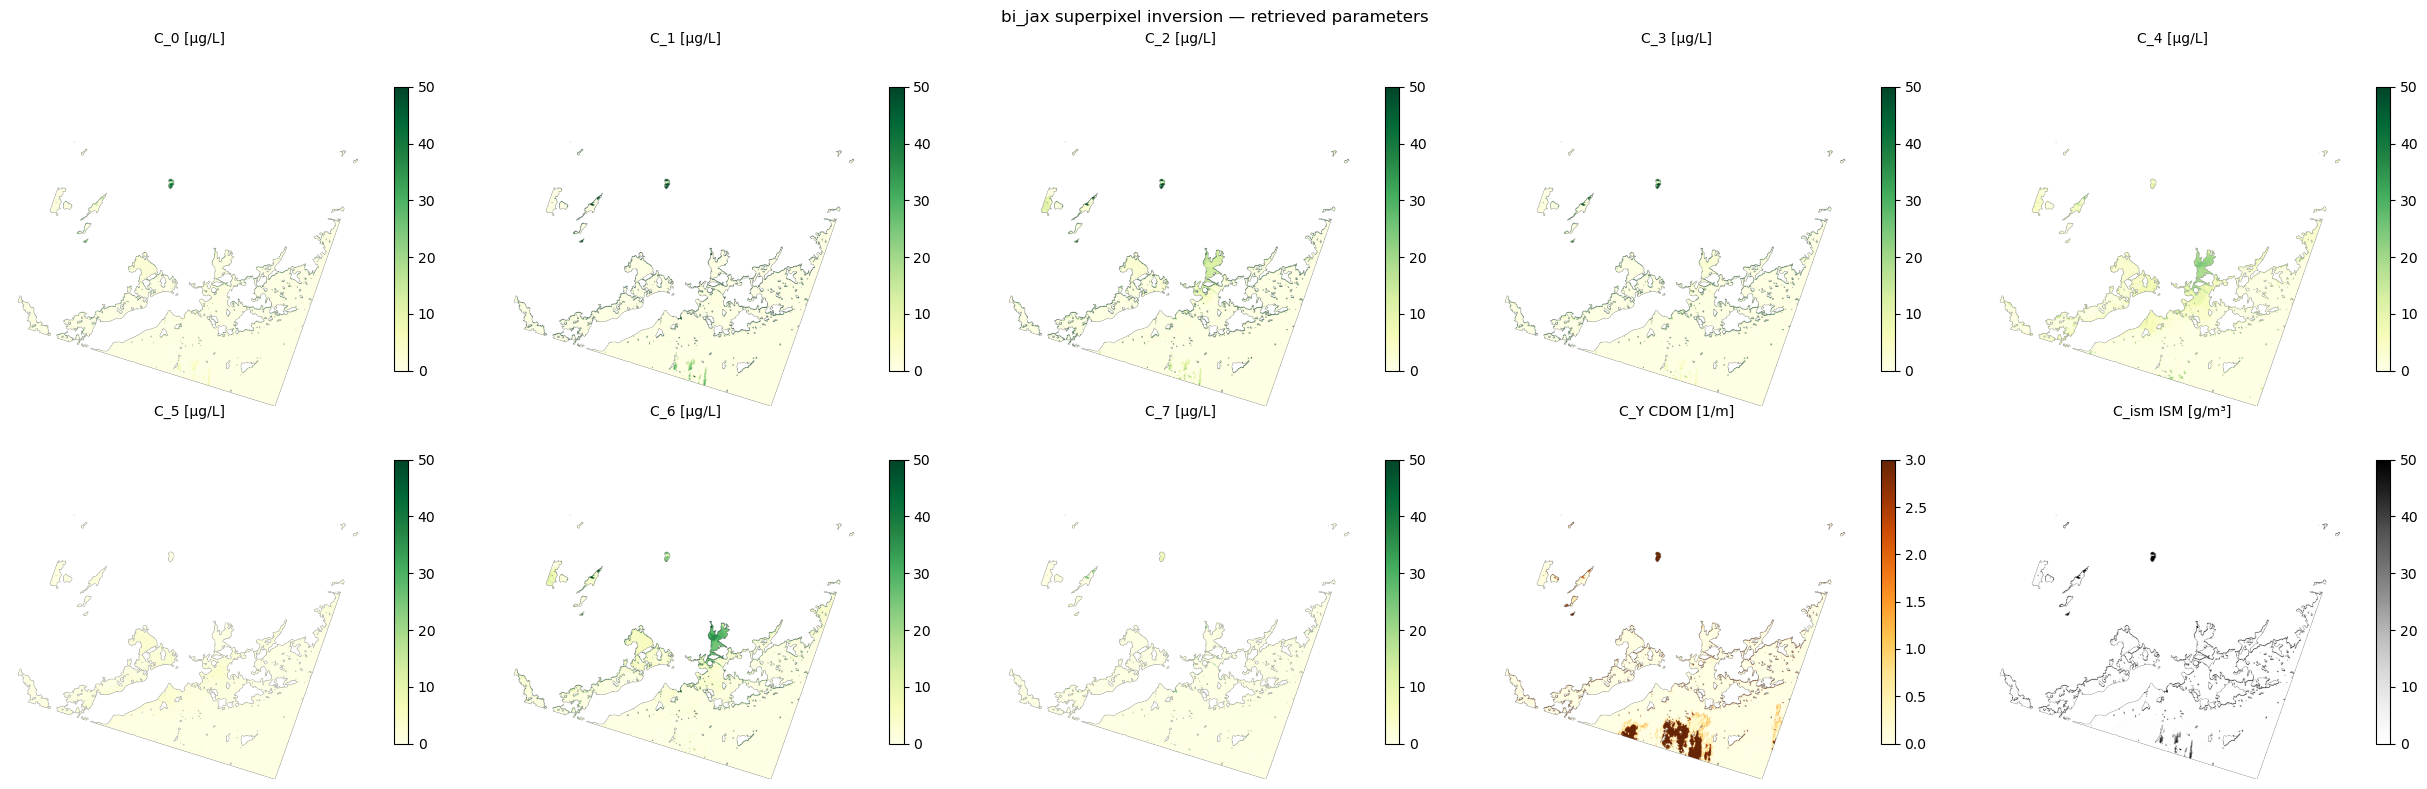

In [10]:
# --- per-parameter maps -----------------------------------------------------
n_params = len(fit_names)
ncols = 5
nrows = int(np.ceil(n_params / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat = axes.ravel() if nrows > 1 else list(axes)

_style = {
    'C_Y':    ('YlOrBr', 0, 3,   'C_Y CDOM [1/m]'),
    'C_ism':  ('Greys',  0, 50,  'C_ism ISM [g/m³]'),
    'offset': ('RdBu',  -0.005, 0.005, 'offset [sr⁻¹]'),
}

for ax, name in zip(axes_flat, fit_names):
    idx = fit_names.index(name)
    if name in _style:
        cmap, vmin, vmax, title = _style[name]
    else:
        cmap, vmin, vmax, title = 'YlGn', 0, 50, f'{name} [µg/L]'
    im = ax.imshow(x_hat[..., idx], cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

for ax in axes_flat[n_params:]:
    ax.axis('off')

plt.suptitle('bi_jax superpixel inversion — retrieved parameters', fontsize=12)
plt.tight_layout()

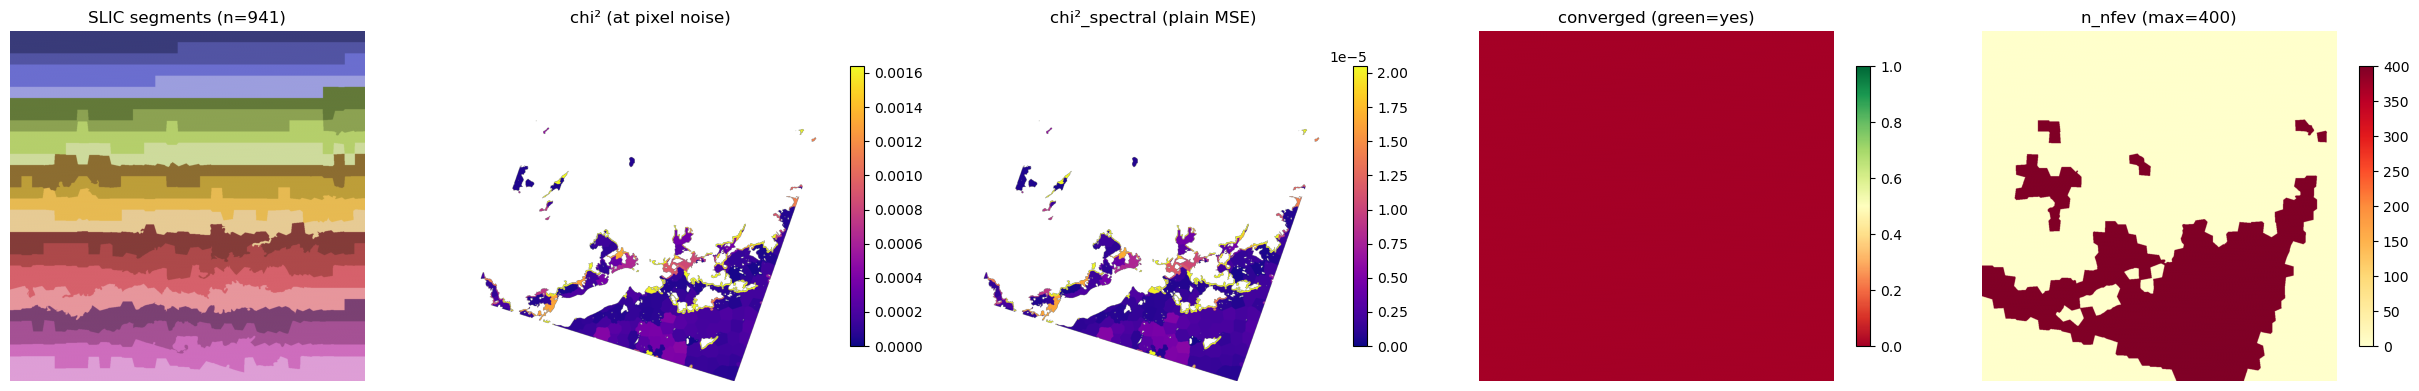

In [11]:
# --- superpixel segment map + chi2 + convergence ----------------------------
fig, axes = plt.subplots(1, 5, figsize=(25, 4))

axes[0].imshow(labels, cmap='tab20b')
axes[0].set_title(f'SLIC segments (n={len(np.unique(labels))})')
axes[0].axis('off')

im1 = axes[1].imshow(chi2, cmap='plasma', vmin=0, vmax=np.nanpercentile(chi2, 95))
plt.colorbar(im1, ax=axes[1], shrink=0.8)
axes[1].set_title('chi² (at pixel noise)')
axes[1].axis('off')

im2 = axes[2].imshow(chi2_sp, cmap='plasma', vmin=0, vmax=np.nanpercentile(chi2_sp[np.isfinite(chi2_sp)], 95))
plt.colorbar(im2, ax=axes[2], shrink=0.8)
axes[2].set_title('chi²_spectral (plain MSE)')
axes[2].axis('off')

im3 = axes[3].imshow(success.astype(float), cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im3, ax=axes[3], shrink=0.8)
axes[3].set_title('converged (green=yes)')
axes[3].axis('off')

im4 = axes[4].imshow(n_nfev, cmap='YlOrRd', vmin=0, vmax=MAX_NFEV)
plt.colorbar(im4, ax=axes[4], shrink=0.8)
axes[4].set_title(f'n_nfev (max={MAX_NFEV})')
axes[4].axis('off')

plt.tight_layout()

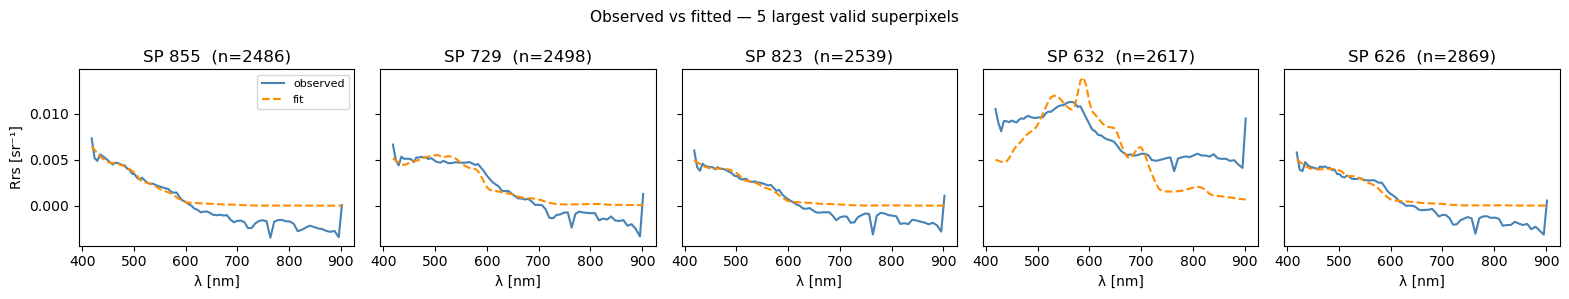

In [12]:
from bio_optics.image_processing.superpixel_engine import aggregate_superpixels

sp_obs, _  = aggregate_superpixels(Rrs_arr, labels)   # (n_segs, n_obs) observed means
sp_x_hat   = results['sp_results']['x_hat']            # (n_segs, n_fit)

# pick 5 largest superpixels with a valid (all-finite) observed mean spectrum
valid_mask = np.isfinite(sp_obs).all(axis=1)
valid_idx  = np.where(valid_mask)[0]
top5_idx   = valid_idx[np.argsort(sp_counts[valid_idx])[-5:]]

fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=True)
for ax, idx in zip(axes, top5_idx):
    obs = sp_obs[idx]
    p_fit = params.copy()
    for name, val in zip(fit_names, sp_x_hat[idx]):
        p_fit[name].value = val
    fit = forward_func(p_fit, wavelengths)

    ax.plot(wavelengths, obs, color='steelblue',   label='observed')
    ax.plot(wavelengths, fit, color='darkorange', ls='--', label='fit')
    ax.set_title(f'SP {idx}  (n={sp_counts[idx]})')
    ax.set_xlabel('λ [nm]')
    if ax is axes[0]:
        ax.set_ylabel('Rrs [sr⁻¹]')
        ax.legend(fontsize=8)

plt.suptitle('Observed vs fitted — 5 largest valid superpixels', fontsize=11)
plt.tight_layout()